---
# Henon as xsuite line
---

(see P. Bélanger thesis, eq.(5.21)-(5.22))

In [1]:
import json
import pathlib
import numpy as np
import pytori as pt
import nafflib

import matplotlib.pyplot as plt
import pytori.plotting as ptplt

import xobjects as xo
import xtrack as xt

# BEAM
#=========================================================================================
nrj             = 7000e9
nemitt_x        = 2.5e-6
nemitt_y        = 2.5e-6
#-----------------------------------------------------------------------------------------
context         = xo.ContextCpu(omp_num_threads='auto')
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
gemitt_x        = 1 if nemitt_x is None else ( nemitt_x / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_y        = 1 if nemitt_x is None else ( nemitt_y / particle_ref.beta0[0] / particle_ref.gamma0[0])
#=========================================================================================


# CREATING LINE
#=========================================================================================
mux         = 0.2981
twiss_init  = {'betx':180 ,'alfx': 2}
#------------------------------------------
h1  = -1j/4  # non-linear strength parameter, Henon definition
k2l = -1j*8*h1/twiss_init['betx']**(3/2)/gemitt_x**(1/2) # sextupole strength
assert np.imag(k2l) == 0, "k2l should be real"
k2l = np.real(k2l)
#=========================================================================================

length = 1
line = xt.Line( elements={
                    'start_cell': xt.Marker(),
                    '.1'        : xt.Marker(),
                    # ==========================
                    'sext'      : xt.Multipole(knl=[0,0,k2l], ksl=[0,0,0],length=0) ,
                    '.1'        : xt.Marker(),
                    'rot'       : xt.LineSegmentMap(qx=mux,qy=mux,**twiss_init,length=length),
                    # ==========================                    
                    '.2'        : xt.Marker(),
                    'end_cell'  : xt.Marker(),
                    })
#------------------------------------------
line.particle_ref   = particle_ref
line.build_tracker(_context=context)
line.freeze_longitudinal(True)
twiss   = line.twiss4d()
#=========================================================================================






Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


---
# Tracking particles and building tori
---

Tracking:   0%|          | 0/10000 [00:00<?, ?it/s]

/Users/pbelanger/ABPLocal/nafflib/nafflib/indexing.py:165: UserWarning: Large frequency error, consider increasing max_n or max_alias!
  warnings.warn('Large frequency error, consider increasing max_n or max_alias!')


(-1.0, 1.0)

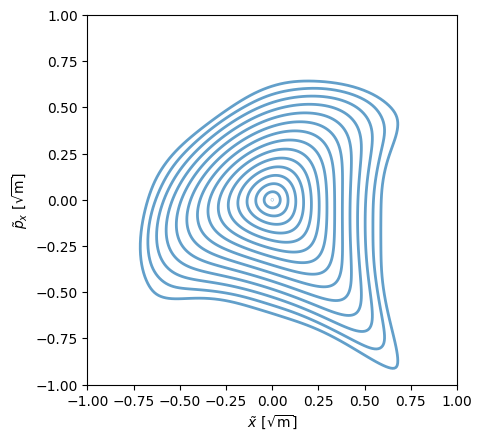

In [2]:
num_turns = int(1e4)

# Initialize particles in CS-normalized phase space
#=======================================================================
particles = line.build_particles(   x_norm   = np.linspace(1e-3,0.8,20),
                                    method   = '4d',
                                    nemitt_x = nemitt_x,
                                    nemitt_y = nemitt_y,
                                    nemitt_zeta     = None,
                                    W_matrix        = twiss.W_matrix[0],
                                    particle_on_co  = twiss.particle_on_co.copy(),
                                    _context        = context)
line.track(particles, num_turns= num_turns,turn_by_turn_monitor=True,with_progress=True)
#=======================================================================

#=======================================================================
naff_buffer = pt.NAFFMonitor()
#---------------------------------------------------------
naff_buffer.twiss        = twiss.get_twiss_init(at_element=twiss.name[0])
naff_buffer.nemitt_x     = nemitt_x
naff_buffer.nemitt_y     = nemitt_y
naff_buffer.nemitt_zeta  = None 
#---------------------------------------------------------
naff_buffer.n_harm       = 100
naff_buffer.window_order = 4
naff_buffer.window_type  = 'hann'
naff_buffer.multiprocesses = 8 # Number of processes for parallel processing
#=======================================================================
# Processing
naff_buffer.process(monitor=line.record_last_track)
naff_df = naff_buffer.to_pandas().groupby('start_at_turn').get_group(0).set_index('particle')
#=======================================================================

trk_tori = []
for pid, naff_row in naff_df.iterrows():
    try:
        # Indexing harmonics
        #============================================================================
        max_n       = 90
        max_alias   = 50
        warning_tol = 1e-7
        Qvec = [naff_row.Qx[0]]
        nx  = nafflib.linear_combinations(naff_row.Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
        #============================================================================

        _torus = pt.Torus.from_naff(n=[nx],A=[naff_row.Ax])
        trk_tori.append(_torus)
    except:
        trk_tori.append(None)
    # display(_torus)






# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

# Plotting
#--------------------------------------------------
plt.figure()
for torus in trk_tori:
    if torus is None:
        continue
    
    ptplt.xloop(torus,num_points=200,edgecolor='C0',alpha=0.7,lw=2)



plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$\tilde x\ [\sqrt{\mathrm{m}}]$');
plt.ylabel(r'$\tilde p_x\ [\sqrt{\mathrm{m}}]$');
plt.xlim([-1,1])
plt.ylim([-1,1])


---
# Physical phase space
### Option 1: transform CS-tori
---

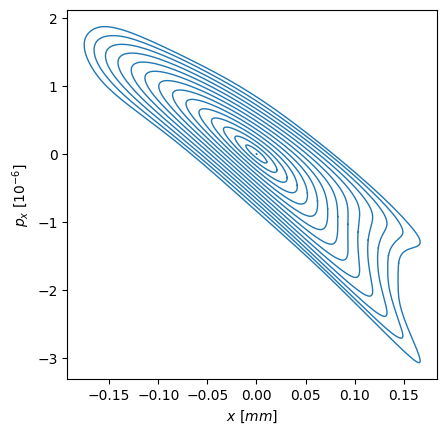

In [3]:
phys_tori = []
for torus in trk_tori:
    # Conversion to physical coordinates
    if torus is None:
        phys_tori.append(None)
        continue

    _torus = pt.transforms.norm2phys(torus.copy(),
                                    W_matrix=twiss.W_matrix[0][:2,:2],
                                    nemitt_x=nemitt_x, 
                                    nemitt_y=nemitt_y, 
                                    particle_on_co=twiss.particle_on_co.copy())
    phys_tori.append(_torus)



# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

# Plotting
#--------------------------------------------------
plt.figure()
for torus in phys_tori:
    if torus is None:
        continue

    # Free hand plot of the torus (easier to rescale axes)
    Tx = np.linspace(0,2*np.pi,200) # Theta_x values
    plt.plot(torus.X(Tx)/1e-3, torus.PX(Tx)/1e-6,'-',color='C0',lw=1)


plt.gca().set_box_aspect(1) 
plt.xlabel(rf'$x\ [mm]$');
plt.ylabel(rf'$p_x\ [10^{{-6}}]$');


---
# Physical phase space
### Option 2: NAFF directly in phys phase space
---

Tracking:   0%|          | 0/10000 [00:00<?, ?it/s]

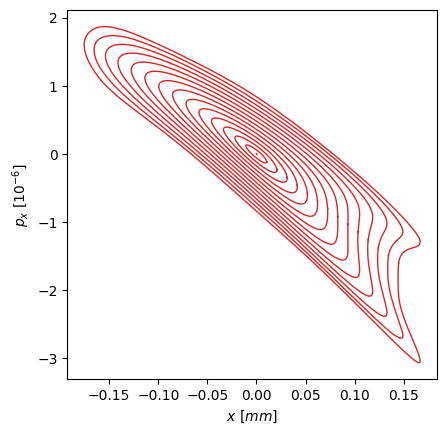

In [4]:
num_turns = int(1e4)

# Initialize particles in CS-normalized phase space anyway
#=======================================================================
particles = line.build_particles(   x_norm   = np.linspace(1e-3,0.8,20),
                                    method   = '4d',
                                    nemitt_x = nemitt_x,
                                    nemitt_y = nemitt_y,
                                    nemitt_zeta     = None,
                                    W_matrix        = twiss.W_matrix[0],
                                    particle_on_co  = twiss.particle_on_co.copy(),
                                    _context        = context)
line.track(particles, num_turns= num_turns,turn_by_turn_monitor=True,with_progress=True)
#=======================================================================

#=======================================================================
naff_buffer = pt.NAFFMonitor(normalize=False)
#---------------------------------------------------------
naff_buffer.n_harm       = 100
naff_buffer.window_order = 4
naff_buffer.window_type  = 'hann'
naff_buffer.multiprocesses = 8 # Number of processes for parallel processing
#=======================================================================
# Processing
naff_buffer.process(monitor=line.record_last_track)
naff_df = naff_buffer.to_pandas().groupby('start_at_turn').get_group(0).set_index('particle')
#=======================================================================

trkphys_tori = []
for pid, naff_row in naff_df.iterrows():
    try:
        # Indexing harmonics
        #============================================================================
        max_n       = 90
        max_alias   = 50
        warning_tol = 1e-7
        Qvec = [naff_row.Qx[0]]
        nx  = nafflib.linear_combinations(naff_row.Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
        #============================================================================

        _torus = pt.Torus.from_naff(n=[nx],A=[naff_row.Ax])
        trkphys_tori.append(_torus)
    except:
        trkphys_tori.append(None)
    # display(_torus)




# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

# Plotting
#--------------------------------------------------
plt.figure()
for torus in trkphys_tori:
    if torus is None:
        continue
    
    # Free hand plot of the torus (easier to rescale axes)
    Tx = np.linspace(0,2*np.pi,200) # Theta_x values
    plt.plot(torus.X(Tx)/1e-3, torus.PX(Tx)/1e-6,'-',color='C3',lw=1)


plt.gca().set_box_aspect(1) 
plt.xlabel(rf'$x\ [mm]$');
plt.ylabel(rf'$p_x\ [10^{{-6}}]$');

